# Requirement Setup

In [1]:
!pip install prophet
!pip install scikit-learn
!pip install tensorflow
%pip install setuptools

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from prophet.serialize import model_from_json
from keras.models import load_model
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

Importing plotly failed. Interactive plots will not work.


In [4]:
np.random.seed(42)
tf.random.set_seed(42)

# Data Loading

Kubernetes Metrics Dataset (Direct Pod Count Prediction)

In [5]:
raw_df = pd.read_csv('data.csv', parse_dates=['timestamp'])
primary_service = raw_df['service_id'].mode()[0]
df_pods = raw_df[raw_df['service_id'] == primary_service].copy()
df_pods = df_pods.sort_values('timestamp').drop_duplicates(subset='timestamp')
df_pods.rename(columns={'timestamp': 'ds', 'current_pod_count': 'actual_pods'}, inplace=True)
feature_cols = [c for c in df_pods.columns if c not in ['ds', 'service_id', 'actual_pods']]

print(f'Using service: {primary_service}')
print(f'Dataset length: {len(df_pods)} | Feature count: {len(feature_cols)}')
df_pods[['ds', 'actual_pods']].head()

Using service: Order
Dataset length: 43200 | Feature count: 20


,ds,actual_pods
0,2025-11-01 00:00:00,2
1,2025-11-01 00:01:00,2
2,2025-11-01 00:02:00,2
3,2025-11-01 00:03:00,2
4,2025-11-01 00:04:00,2


Select Evaluation Time Window

In [6]:
# Select last 9 days for evaluation (test period)
start_time = pd.to_datetime("2025-11-22 00:00:00")
end_time = pd.to_datetime("2025-12-01 00:00:00")
df_pods = df_pods[(df_pods['ds'] >= start_time) & (df_pods['ds'] <= end_time)].reset_index(drop=True)

print(f'POD DATASET - Records: {len(df_pods)} | Date Range: {df_pods["ds"].min()} to {df_pods["ds"].max()}')
df_pods.head()

POD DATASET - Records: 12960 | Date Range: 2025-11-22 00:00:00 to 2025-11-30 23:59:00


,ds,service_id,actual_pods,request_rate_rps,latency_p95_ms,latency_p99_ms,error_rate_percent,queue_length,pod_cpu_usage_percent_avg,pod_cpu_usage_percent_p95,...,hour_cos,day_sin,day_cos,mesh_inbound_rps,mesh_inbound_latency_p95,mesh_inbound_error_rate,degree_centrality,eigenvector_centrality,betweenness_centrality,closeness_centrality
0,2025-11-22 00:00:00,Order,5,88.45,49.25,61.67,0.0374,0.0,17.55,20.57,...,1.0,-0.9749,-0.2225,89.17,47.23,0.0401,0.7887,0.8842,0.6681,0.7469
1,2025-11-22 00:01:00,Order,5,70.17,50.89,70.05,0.0362,0.0,18.97,21.27,...,1.0,-0.9749,-0.2225,70.24,48.26,0.0391,0.8170,0.8859,0.6611,0.7088
2,2025-11-22 00:02:00,Order,3,64.17,52.17,67.15,0.0355,0.0,17.91,20.41,...,1.0,-0.9749,-0.2225,65.37,49.18,0.0372,0.7643,0.8860,0.6601,0.7491
3,2025-11-22 00:03:00,Order,3,65.33,52.24,70.28,0.0353,0.0,19.95,24.60,...,1.0,-0.9749,-0.2225,65.90,51.14,0.0388,0.8260,0.8782,0.6920,0.7177
4,2025-11-22 00:04:00,Order,3,67.57,53.84,65.95,0.0354,0.0,24.91,29.87,...,1.0,-0.9749,-0.2225,66.31,51.31,0.0362,0.8612,0.8819,0.6569,0.7351


Scale data (model was trained on scaled data)

In [8]:
target_scaler = MinMaxScaler(feature_range=(0, 1))
feature_scaler = MinMaxScaler()

# Fit scalers on full dataset range for consistency
full_df = raw_df[raw_df['service_id'] == primary_service].copy()
target_scaler.fit(full_df[['current_pod_count']])
feature_scaler.fit(full_df[[c for c in full_df.columns if c not in ['timestamp', 'service_id', 'current_pod_count']]])

# Transform - use correct column name for target scaler
df_pods['y'] = target_scaler.transform(df_pods[['actual_pods']].rename(columns={'actual_pods': 'current_pod_count'}))
df_pods[feature_cols] = feature_scaler.transform(df_pods[feature_cols])

# Load Trained Models

In [10]:
with open('models/fbprophet-pods-20260101_174958.json', 'r') as f:
    prophet_model = model_from_json(f.read())

lstm_model = load_model('models/lstm-pods-20260101_174958.keras')

# Prophet Prediction (Baseline Pod Count)

In [11]:
forecast_df_pods = prophet_model.predict(df_pods[['ds']].copy())

# Residual Calculation & Preparation

In [12]:
df_pods_residual = df_pods.merge(forecast_df_pods[['ds', 'yhat']], on='ds', how='left')
df_pods_residual['residual'] = df_pods_residual['y'] - df_pods_residual['yhat']
residual_feature_cols = feature_cols + ['residual']

In [13]:
def create_dataset(features, target, look_back):
    X, y = [], []
    features = np.array(features)
    target = np.array(target)
    for i in range(len(target) - look_back):
        X.append(features[i:i + look_back, :])
        y.append(target[i + look_back])
    return np.array(X), np.array(y)

In [14]:
look_back = 1
X_pods, y_pods = create_dataset(df_pods_residual[residual_feature_cols], df_pods_residual['residual'], look_back)

# LSTM Residual Prediction

In [15]:
pods_predict = lstm_model.predict(X_pods)

405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


# Calculate Final Pod Count Prediction (Direct - No Conversion Needed)

In [16]:
final_df_pods = df_pods_residual.copy()

final_df_pods['residual_predict'] = np.nan
final_df_pods.iloc[0:len(pods_predict), final_df_pods.columns.get_loc('residual_predict')] = pods_predict[:, 0]
print(f'POD DATASET: Total Output: {final_df_pods.shape[0]} | Missing: {final_df_pods["residual_predict"].isna().sum()}')

final_df_pods['residual_predict'] = final_df_pods['residual_predict'].fillna(final_df_pods['residual'])

# Combine Prophet baseline + LSTM residual = final scaled prediction
final_df_pods['y_predicted_scaled'] = final_df_pods['yhat'] + final_df_pods['residual_predict']

# Inverse transform to get actual pod counts
final_df_pods['pba_pods'] = target_scaler.inverse_transform(final_df_pods[['y_predicted_scaled']])
final_df_pods['pba_pods'] = np.maximum(1, np.round(final_df_pods['pba_pods'])).astype(int)  # Round and ensure min 1 pod

final_df_pods.head()

POD DATASET: Total Output: 12960 | Missing: 1


,ds,service_id,actual_pods,request_rate_rps,latency_p95_ms,latency_p99_ms,error_rate_percent,queue_length,pod_cpu_usage_percent_avg,pod_cpu_usage_percent_p95,...,degree_centrality,eigenvector_centrality,betweenness_centrality,closeness_centrality,y,yhat,residual,residual_predict,y_predicted_scaled,pba_pods
0,2025-11-22 00:00:00,Order,5,0.032649,0.018709,0.017137,0.002856,0.0,0.099468,0.091626,...,0.321545,0.545528,0.565707,0.684874,0.107143,0.094849,0.012293,0.014162,0.109011,5
1,2025-11-22 00:01:00,Order,5,0.024227,0.023918,0.036490,0.002265,0.0,0.118351,0.099190,...,0.453234,0.559226,0.534203,0.456182,0.107143,0.092530,0.014613,0.015108,0.107638,5
2,2025-11-22 00:02:00,Order,3,0.021462,0.027983,0.029793,0.001920,0.0,0.104255,0.089897,...,0.208004,0.560032,0.529703,0.698079,0.035714,0.090183,-0.054469,-0.046496,0.043687,3
3,2025-11-22 00:03:00,Order,3,0.021996,0.028206,0.037022,0.001822,0.0,0.131383,0.135170,...,0.495114,0.497180,0.673267,0.509604,0.035714,0.087842,-0.052128,-0.046051,0.041791,3
4,2025-11-22 00:04:00,Order,3,0.023029,0.033288,0.027021,0.001871,0.0,0.197340,0.192112,...,0.658911,0.526994,0.515302,0.614046,0.035714,0.085537,-0.049823,-0.045012,0.040525,3


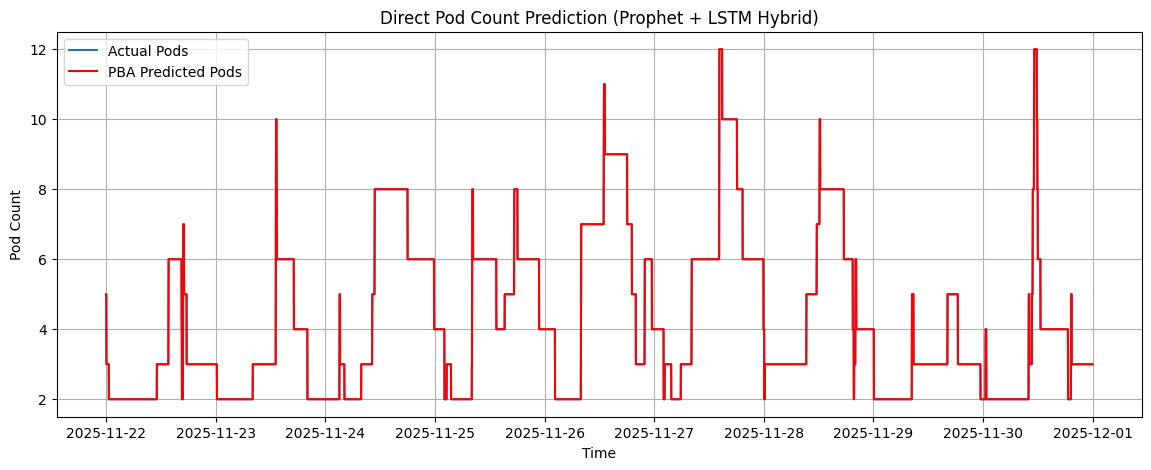

In [17]:
plt.figure(figsize=(14, 5))
plt.plot(final_df_pods['ds'], final_df_pods['actual_pods'], label='Actual Pods', color='#1f77b4')
plt.plot(final_df_pods['ds'], final_df_pods['pba_pods'], label='PBA Predicted Pods', color='red')
plt.title('Direct Pod Count Prediction (Prophet + LSTM Hybrid)')
plt.xlabel('Time')
plt.ylabel('Pod Count')
plt.grid(True)
plt.legend()
plt.show()

# HPA Simulation for Comparison

HPA Constants
- CPU Threshold: 0.7
- Scale Down Delay: 5 min
- Minimum Pods: 1

In [20]:
cpu_threshold = 0.7
scale_down_delay = 5
pods_min = 1

In [21]:
pod_df = final_df_pods.copy()

In [22]:
# HPA simulation using CPU metrics from the dataset
# HPA scales based on average CPU usage relative to threshold
pod_df['hpa_pods'] = pods_min
last_scale_down_time = None

# Use pod_cpu_usage_percent_avg from original data for HPA decisions
cpu_col = 'pod_cpu_usage_percent_avg'
cpu_data = raw_df[raw_df['service_id'] == primary_service].copy()
cpu_data = cpu_data[(cpu_data['timestamp'] >= start_time) & (cpu_data['timestamp'] <= end_time)].reset_index(drop=True)

pod_df.loc[0, 'hpa_pods'] = pod_df.loc[0, 'actual_pods']

for i in range(1, len(pod_df)):
    current_pods = int(pod_df.loc[i - 1, 'hpa_pods'])
    current_cpu = cpu_data.loc[i, cpu_col] / 100.0 if i < len(cpu_data) else 0.5
    
    # HPA formula: desired = ceil(current * (currentMetric / desiredMetric))
    desired_pods = int(np.ceil(current_pods * (current_cpu / cpu_threshold)))
    desired_pods = max(pods_min, desired_pods)
    
    if desired_pods > current_pods:
        # Scale Up immediately
        pod_df.loc[i, 'hpa_pods'] = desired_pods
        last_scale_down_time = None
    elif desired_pods < current_pods:
        # Scale Down with delay
        if last_scale_down_time is None:
            last_scale_down_time = pod_df.loc[i, 'ds']
            pod_df.loc[i, 'hpa_pods'] = current_pods
        elif (pod_df.loc[i, 'ds'] - last_scale_down_time).total_seconds() / 60 >= scale_down_delay:
            pod_df.loc[i, 'hpa_pods'] = desired_pods
            last_scale_down_time = pod_df.loc[i, 'ds']
        else:
            pod_df.loc[i, 'hpa_pods'] = current_pods
    else:
        pod_df.loc[i, 'hpa_pods'] = current_pods

pod_df['hpa_pods'] = pod_df['hpa_pods'].astype(int)

In [23]:
pod_df[['ds', 'actual_pods', 'pba_pods', 'hpa_pods']].head(10)

,ds,actual_pods,pba_pods,hpa_pods
0,2025-11-22 00:00:00,5,5,5
1,2025-11-22 00:01:00,5,5,5
2,2025-11-22 00:02:00,3,3,5
3,2025-11-22 00:03:00,3,3,5
4,2025-11-22 00:04:00,3,3,5
5,2025-11-22 00:05:00,3,3,5
6,2025-11-22 00:06:00,3,3,2
7,2025-11-22 00:07:00,3,3,2
8,2025-11-22 00:08:00,3,3,2
9,2025-11-22 00:09:00,3,3,2


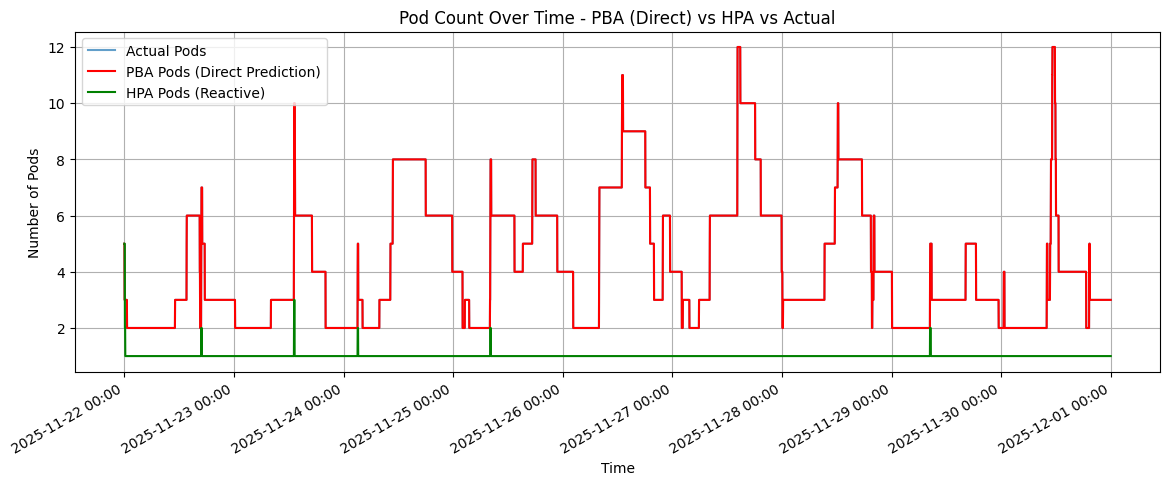

In [24]:
plt.figure(figsize=(14, 5))
plt.plot(pod_df['ds'], pod_df['actual_pods'], label='Actual Pods', color='#1f77b4', alpha=0.7)
plt.plot(pod_df['ds'], pod_df['pba_pods'], label='PBA Pods (Direct Prediction)', color='red')
plt.plot(pod_df['ds'], pod_df['hpa_pods'], label='HPA Pods (Reactive)', color='green')
plt.title('Pod Count Over Time - PBA (Direct) vs HPA vs Actual')
plt.xlabel('Time')
plt.ylabel('Number of Pods')
plt.grid(True)
plt.legend()

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.gcf().autofmt_xdate() 

plt.show()

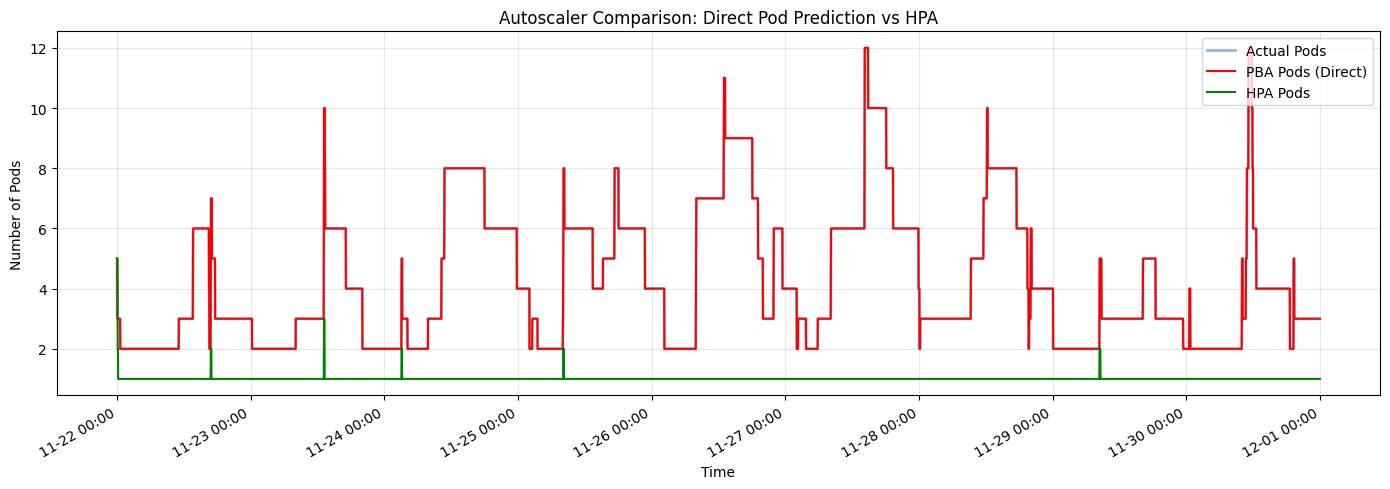

In [25]:
fig, ax1 = plt.subplots(figsize=(14, 5))

line1 = ax1.plot(pod_df['ds'], pod_df['actual_pods'], label='Actual Pods', color='#1f77b4', alpha=0.5, linewidth=2)
line2 = ax1.plot(pod_df['ds'], pod_df['pba_pods'], label='PBA Pods (Direct)', color='red', linewidth=1.5)
line3 = ax1.plot(pod_df['ds'], pod_df['hpa_pods'], label='HPA Pods', color='green', linewidth=1.5)

ax1.set_title('Autoscaler Comparison: Direct Pod Prediction vs HPA')
ax1.set_xlabel('Time')
ax1.set_ylabel('Number of Pods')
ax1.grid(True, alpha=0.3)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=1))
fig.autofmt_xdate()

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.show()

# Evaluation Metrics

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df_analysis = pod_df.copy()
total_time = len(df_analysis)  # Total minutes

# === PBA Metrics ===
df_analysis['pba_under'] = np.maximum(df_analysis['actual_pods'] - df_analysis['pba_pods'], 0)
df_analysis['pba_over'] = np.maximum(df_analysis['pba_pods'] - df_analysis['actual_pods'], 0)
df_analysis['pba_sgn_under'] = np.where(df_analysis['actual_pods'] > df_analysis['pba_pods'], 1, 0)
df_analysis['pba_sgn_over'] = np.where(df_analysis['pba_pods'] > df_analysis['actual_pods'], 1, 0)

# === HPA Metrics ===
df_analysis['hpa_under'] = np.maximum(df_analysis['actual_pods'] - df_analysis['hpa_pods'], 0)
df_analysis['hpa_over'] = np.maximum(df_analysis['hpa_pods'] - df_analysis['actual_pods'], 0)
df_analysis['hpa_sgn_under'] = np.where(df_analysis['actual_pods'] > df_analysis['hpa_pods'], 1, 0)
df_analysis['hpa_sgn_over'] = np.where(df_analysis['hpa_pods'] > df_analysis['actual_pods'], 1, 0)

# Provisioning metrics (percentage based)
# Θ_U = under-provisioning magnitude, Θ_O = over-provisioning magnitude
# T_U = under-provisioning time fraction, T_O = over-provisioning time fraction

print("=" * 60)
print("PREDICTION-BASED AUTOSCALER (PBA) - Direct Pod Prediction")
print("=" * 60)

pba_mse = mean_squared_error(df_analysis['actual_pods'], df_analysis['pba_pods'])
pba_rmse = np.sqrt(pba_mse)
pba_mae = mean_absolute_error(df_analysis['actual_pods'], df_analysis['pba_pods'])
pba_r2 = r2_score(df_analysis['actual_pods'], df_analysis['pba_pods'])

pba_Θ_U = (100 / total_time) * (df_analysis['pba_under'] / df_analysis['actual_pods'].replace(0, 1)).sum()
pba_Θ_O = (100 / total_time) * (df_analysis['pba_over'] / df_analysis['actual_pods'].replace(0, 1)).sum()
pba_T_U = (100 / total_time) * df_analysis['pba_sgn_under'].sum()
pba_T_O = (100 / total_time) * df_analysis['pba_sgn_over'].sum()

print(f'MSE: {pba_mse:.4f}')
print(f'RMSE: {pba_rmse:.4f}')
print(f'MAE: {pba_mae:.4f}')
print(f'R²: {pba_r2:.4f}')
print(f'Under-provisioning (Θ_U): {pba_Θ_U:.2f}%')
print(f'Over-provisioning (Θ_O): {pba_Θ_O:.2f}%')
print(f'Under-provisioning Time (T_U): {pba_T_U:.2f}%')
print(f'Over-provisioning Time (T_O): {pba_T_O:.2f}%')

print("\n" + "=" * 60)
print("HORIZONTAL POD AUTOSCALER (HPA) - Reactive")
print("=" * 60)

hpa_mse = mean_squared_error(df_analysis['actual_pods'], df_analysis['hpa_pods'])
hpa_rmse = np.sqrt(hpa_mse)
hpa_mae = mean_absolute_error(df_analysis['actual_pods'], df_analysis['hpa_pods'])
hpa_r2 = r2_score(df_analysis['actual_pods'], df_analysis['hpa_pods'])

hpa_Θ_U = (100 / total_time) * (df_analysis['hpa_under'] / df_analysis['actual_pods'].replace(0, 1)).sum()
hpa_Θ_O = (100 / total_time) * (df_analysis['hpa_over'] / df_analysis['actual_pods'].replace(0, 1)).sum()
hpa_T_U = (100 / total_time) * df_analysis['hpa_sgn_under'].sum()
hpa_T_O = (100 / total_time) * df_analysis['hpa_sgn_over'].sum()

print(f'MSE: {hpa_mse:.4f}')
print(f'RMSE: {hpa_rmse:.4f}')
print(f'MAE: {hpa_mae:.4f}')
print(f'R²: {hpa_r2:.4f}')
print(f'Under-provisioning (Θ_U): {hpa_Θ_U:.2f}%')
print(f'Over-provisioning (Θ_O): {hpa_Θ_O:.2f}%')
print(f'Under-provisioning Time (T_U): {hpa_T_U:.2f}%')
print(f'Over-provisioning Time (T_O): {hpa_T_O:.2f}%')

print("\n" + "=" * 60)
print("COMPARISON SUMMARY")
print("=" * 60)
print(f'PBA RMSE Improvement: {((hpa_rmse - pba_rmse) / hpa_rmse * 100):.2f}%')
print(f'PBA MAE Improvement: {((hpa_mae - pba_mae) / hpa_mae * 100):.2f}%')
print(f'PBA Under-prov Reduction: {((hpa_Θ_U - pba_Θ_U) / max(hpa_Θ_U, 0.001) * 100):.2f}%')
print(f'PBA Over-prov Reduction: {((hpa_Θ_O - pba_Θ_O) / max(hpa_Θ_O, 0.001) * 100):.2f}%')

PREDICTION-BASED AUTOSCALER (PBA) - Direct Pod Prediction
MSE: 0.0023
RMSE: 0.0481
MAE: 0.0020
R²: 0.9995
Under-provisioning (Θ_U): 0.00%
Over-provisioning (Θ_O): 0.05%
Under-provisioning Time (T_U): 0.00%
Over-provisioning Time (T_O): 0.19%

HORIZONTAL POD AUTOSCALER (HPA) - Reactive
MSE: 15.3213
RMSE: 3.9142
MAE: 3.2077
R²: -2.0383
Under-provisioning (Θ_U): 69.26%
Over-provisioning (Θ_O): 0.02%
Under-provisioning Time (T_U): 99.95%
Over-provisioning Time (T_O): 0.03%

COMPARISON SUMMARY
PBA RMSE Improvement: 98.77%
PBA MAE Improvement: 99.94%
PBA Under-prov Reduction: 100.00%
PBA Over-prov Reduction: -149.63%


# Inference Latency Comparison

In [27]:
import time

# Measure inference latency for single prediction
test_input_prophet = df_pods[['ds']].iloc[[0]].copy()
test_features = df_pods_residual[residual_feature_cols].iloc[[0]].values.reshape(1, look_back, -1)

# Prophet latency
n_runs = 100
prophet_times = []
for _ in range(n_runs):
    start = time.perf_counter()
    _ = prophet_model.predict(test_input_prophet)
    prophet_times.append((time.perf_counter() - start) * 1000)

# LSTM latency
lstm_times = []
for _ in range(n_runs):
    start = time.perf_counter()
    _ = lstm_model.predict(test_features, verbose=0)
    lstm_times.append((time.perf_counter() - start) * 1000)

# Combined (sequential)
combined_times = []
for _ in range(n_runs):
    start = time.perf_counter()
    prophet_out = prophet_model.predict(test_input_prophet)
    _ = lstm_model.predict(test_features, verbose=0)
    combined_times.append((time.perf_counter() - start) * 1000)

print("=" * 60)
print("INFERENCE LATENCY (Single Prediction)")
print("=" * 60)
print(f"Prophet Mean: {np.mean(prophet_times):.2f}ms (std: {np.std(prophet_times):.2f}ms)")
print(f"LSTM Mean: {np.mean(lstm_times):.2f}ms (std: {np.std(lstm_times):.2f}ms)")
print(f"Combined (Prophet+LSTM): {np.mean(combined_times):.2f}ms (std: {np.std(combined_times):.2f}ms)")
print(f"\nNote: Direct pod prediction eliminates the request-rate-to-pod conversion step")

INFERENCE LATENCY (Single Prediction)
Prophet Mean: 27.13ms (std: 3.65ms)
LSTM Mean: 67.03ms (std: 6.00ms)
Combined (Prophet+LSTM): 92.58ms (std: 12.96ms)

Note: Direct pod prediction eliminates the request-rate-to-pod conversion step
